In [1]:
!pip install kagglehub

import kagglehub

# Download latest version
path = kagglehub.dataset_download("asaniczka/uk-optimal-product-price-prediction")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\llam_\.cache\kagglehub\datasets\asaniczka\uk-optimal-product-price-prediction\versions\3


In [2]:
import pandas as pd
import os

path = r"C:\Users\llam_\.cache\kagglehub\datasets\asaniczka\uk-optimal-product-price-prediction\versions\3"

files = [f for f in os.listdir(path) if f.endswith('.csv')]
file_path = os.path.join(path, files[0])

df = pd.read_csv(file_path)

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
1. **Crosstab Analysis**:
    - Create a crosstab between the product `category` and the `isBestSeller` status.
    
    - Are there categories where being a best-seller is more prevalent? 
    	
    	*Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion in descending order.*

In [9]:
df.head()


,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [10]:
ct = pd.crosstab(df['category'], df['isBestSeller'])

ct_prop = ct.div(ct.sum(1), axis=0)

ct_prop_asc = ct_prop.sort_values(by=True, ascending=False)
print(ct)

print(ct_prop_asc)

isBestSeller                    False  True 
category                                    
3D Printers                       247      1
3D Printing & Scanning           4065      2
Abrasive & Finishing Products     245      5
Action Cameras                   1696      1
Adapters                          251      3
...                               ...    ...
Wind Instruments                  243      7
Window Treatments                 234      5
Women                           17559    213
Women's Sports & Outdoor Shoes   1939     20
eBook Readers & Accessories       246      0

[296 rows x 2 columns]
isBestSeller                       False     True 
category                                          
Grocery                         0.941865  0.058135
Smart Home Security & Lighting  0.942308  0.057692
Health & Personal Care          0.942314  0.057686
Mobile Phone Accessories        0.957529  0.042471
Power & Hand Tools              0.964661  0.035339
...                               

C:\Users\llam_\AppData\Local\Temp\ipykernel_116836\4197200613.py:3: Pandas4Warning: Starting with pandas version 4.0 all arguments of sum will be keyword-only.
  ct_prop = ct.div(ct.sum(1), axis=0)


In [ ]:
#in groceries, smart home sec and health &personal care, best sellers are more prevalents.

In [ ]:
2. **Statistical Tests**:
    - Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
    - Compute Cramér's V to understand the strength of association between best-seller status and category.

In [15]:
!pip install scipy

In [17]:
import sys
!{sys.executable} -m pip install scip

     ---------------------------------------- 0.0/3.6 MB ? eta -:--:--
     ---------------------------------------- 3.6/3.6 MB 33.6 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
INFO: pip is looking at multiple versions of ome-zarr to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of ann

  error: subprocess-exited-with-error
  
  × Building wheel for lxml (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [112 lines of output]
      Building lxml version 4.9.4.
      Building without Cython.
      Building against pre-built libxml2 andl libxslt libraries
      C:\Users\llam_\AppData\Local\Temp\pip-build-env-54m2coxg\overlay\Lib\site-packages\setuptools\dist.py:765: SetuptoolsDeprecationWarning: License classifiers are deprecated.
      !!
      
              ********************************************************************************
              Please consider removing the following classifiers in favor of a SPDX license expression:
      
              License :: OSI Approved :: BSD License
      
              See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
              ********************************************************************************
      
      !!
        self._finalize_license_e

In [18]:
from scipy.stats import chi2_contingency

ModuleNotFoundError: No module named 'scipy'

In [12]:
chi2, p, dof, expect = chi2_contingency(ct)

print(f"P-valor: {p}")

NameError: name 'chi2_contingency' is not defined

In [7]:
import numpy as np

n = ct.sum().sum()

v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

print(f"Cramers: {v}")

NameError: name 'ct' is not defined

In [ ]:
3. **Visualizations**:
	- Visualize the relationship between product categories and the best-seller status using a stacked bar chart.

<Axes: ylabel='category'>

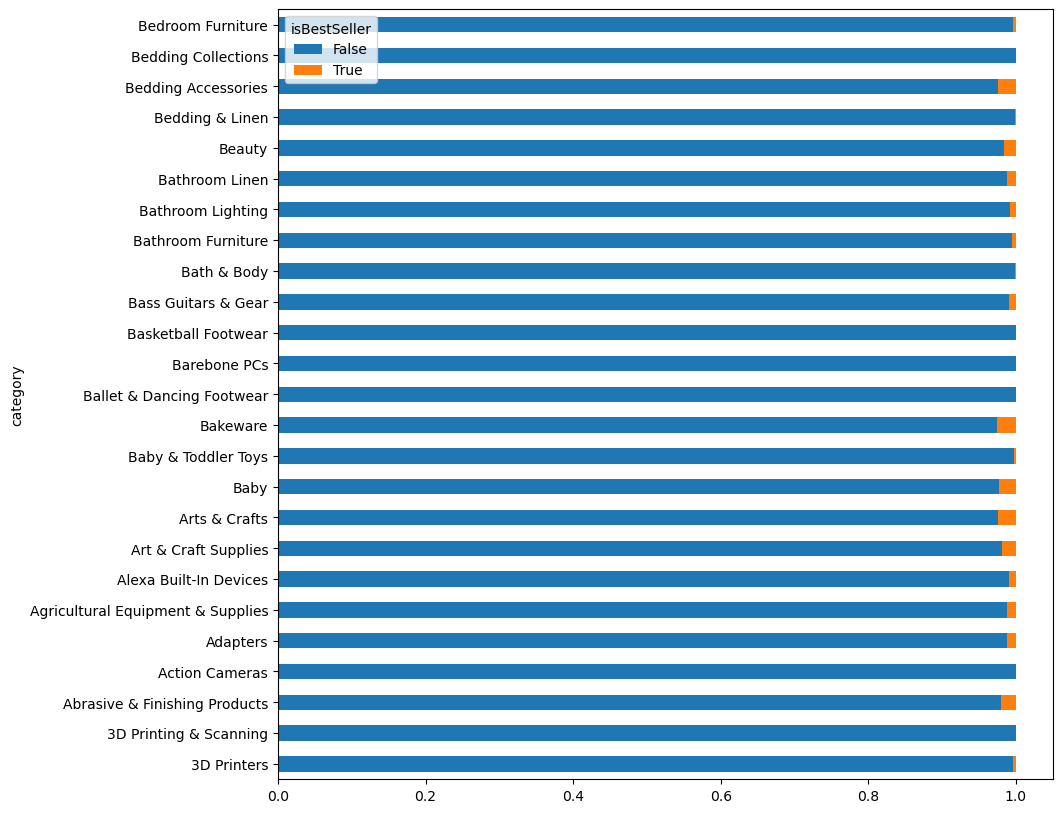

In [ ]:
ct_prop.head(25).plot(kind="barh", stacked=True, figsize=(10,10))

In [ ]:
**Objective**: Investigate how different product categories influence product prices.

0. **Preliminary Step: Remove outliers in product prices.**

	For this purpose, we can use the IQR (Interquartile Range) method. Products priced below the first quartile minus 1.5 times the IQR or above the third quartile plus 1.5 times the IQR will be considered outliers and removed from the dataset. The next steps will be done with the dataframe without outliers.
	
	*Hint: you can check the last Check For Understanding at the end of the lesson EDA Bivariate Analysis for a hint on how to do this.*

In [4]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

print(f"Límite superior de precio: {upper_bound:.2f}")
print(f"Productos eliminados: {len(df) - len(df_clean)}")

Límite superior de precio: 99.99
Productos eliminados: 327688


In [ ]:
1. **Violin Plots**:
    - Use a violin plot to visualize the distribution of `price` across different product `categories`. Filter out the top 20 categories based on count for better visualization.
    - Which product category tends to have the highest median price? Don't filter here by top categories. MAN has de more median price.

In [ ]:
top_20_categories = df_clean['category'].value_counts().head(20).index
df_top20 = df_clean[df_clean['category'].isin(top_20_categories)]


C:\Users\llam_\AppData\Local\Temp\ipykernel_100000\1008640509.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_top20, x='price', y='category', palette="coolwarm")


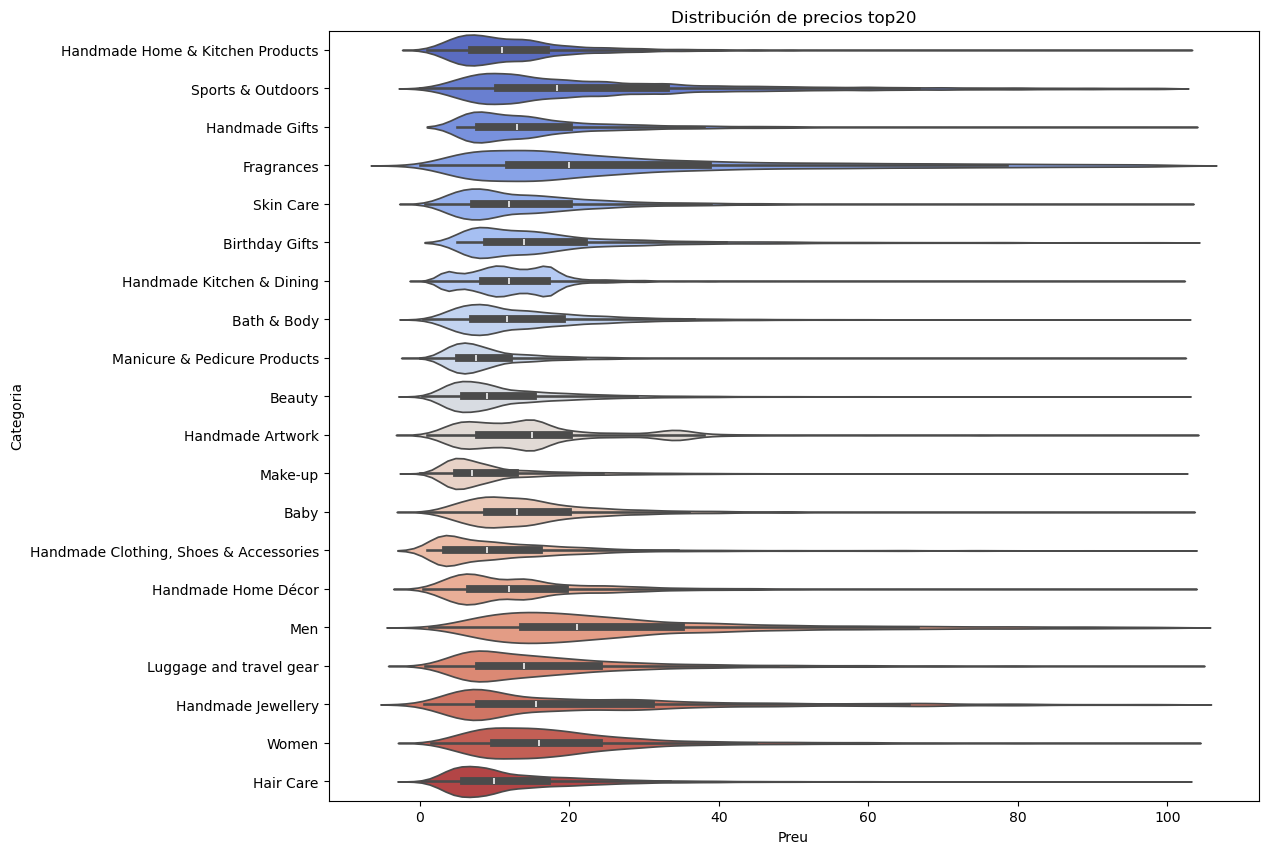

In [ ]:
plt.figure(figsize=(12,10))

sns.violinplot(data=df_top20, x='price', y='category', palette="coolwarm")

plt.title('Distribución de precios top20')
plt.xlabel('Preu')
plt.ylabel('Categoria')
plt.show()

In [ ]:

2. **Bar Charts**:
    - Create a bar chart comparing the average price of products for the top 10 product categories (based on count).
    - Which product category commands the highest average price? Don't filter here by top categories.



In [ ]:
avg_prices = df_clean.groupby('category')['price'].mean().sort_values(ascending=False)
categoria_max_avg = avg_prices.idxmax()
valor_max_avg = avg_prices.max()
 
print(f"La categoria de precio medio mas alto: {categoria_max_avg} ({valor_max_avg:.2f}€)")

La categoria de precio medio mas alto: Motherboards (68.77€)


C:\Users\llam_\AppData\Local\Temp\ipykernel_100000\965213614.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price_top_10, y=avg_price_top_10.index, palette="mako")


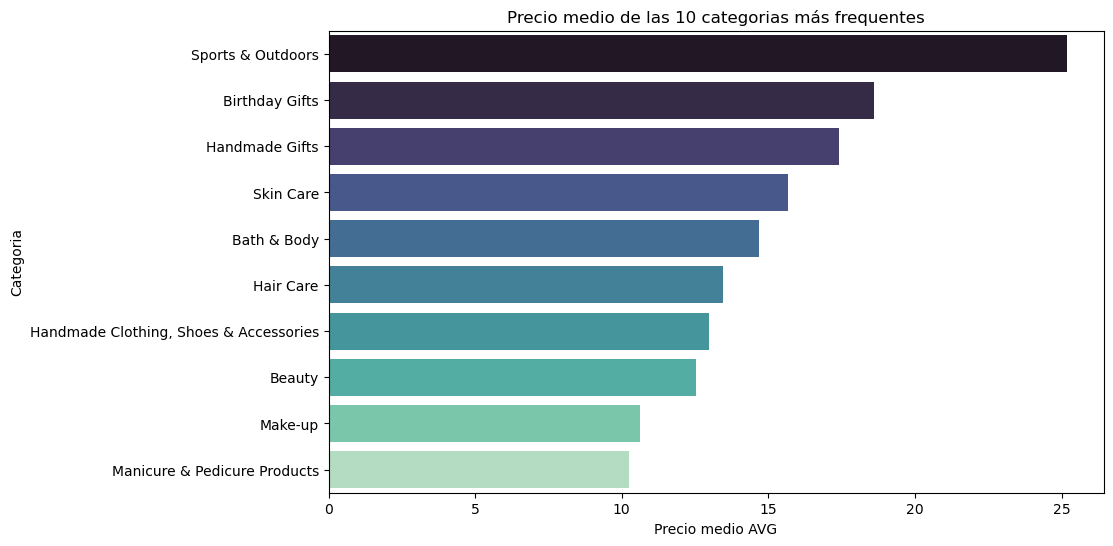

In [ ]:
top_10_names = df_clean['category'].value_counts().head(10).index
avg_price_top_10 = avg_prices.loc[top_10_names].sort_values(ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(x=avg_price_top_10, y=avg_price_top_10.index, palette="mako")

plt.title("Precio medio de las 10 categorias más frequentes")
plt.xlabel("Precio medio AVG")
plt.ylabel("categoria")
plt.show()

In [ ]:
3. **Box Plots**:
    - Visualize the distribution of product `ratings` based on their `category` using side-by-side box plots. Filter out the top 10 categories based on count for better visualization.
    - Which category tends to receive the highest median rating from customers? Don't filter here by top categories.

C:\Users\llam_\AppData\Local\Temp\ipykernel_100000\4292627515.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ratings_top10, x='stars', y='category', palette='Set3')


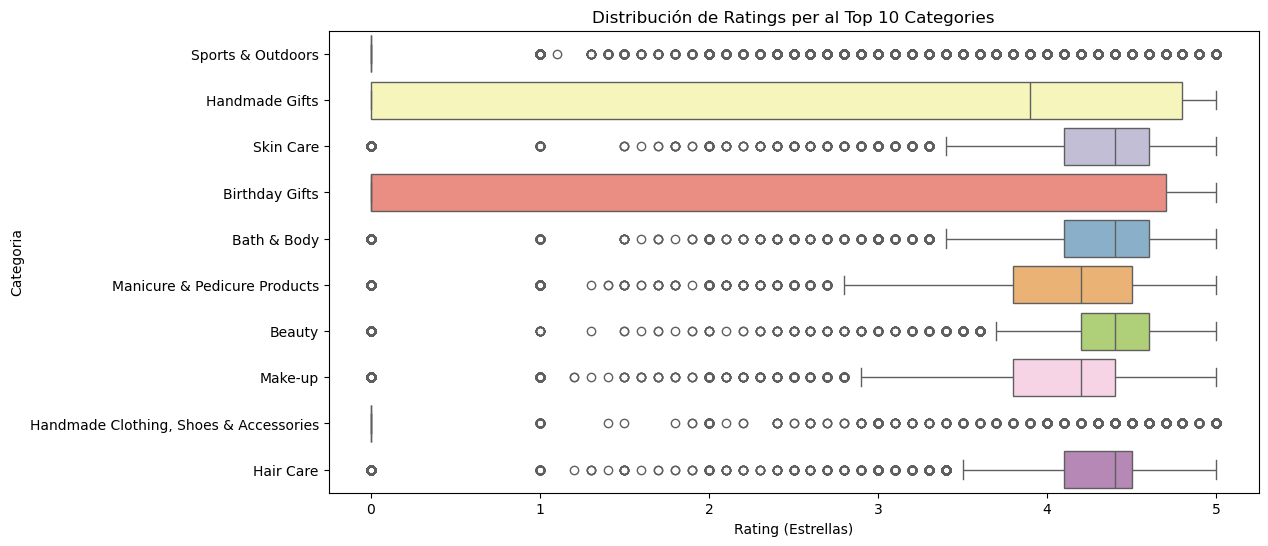

In [ ]:
top_10_freqnames = df_clean['category'].value_counts().head(10).index

df_ratings_top10 = df_clean[df_clean['category'].isin(top_10_freqnames)]

plt.figure(figsize=(12, 6))

sns.boxplot(data=df_ratings_top10, x='stars', y='category', palette='Set3')

plt.title('Distribución de Ratings per al Top 10 Categories')
plt.xlabel('Rating (Estrellas)')
plt.ylabel('Categoria')
plt.show()

C:\Users\llam_\AppData\Local\Temp\ipykernel_100000\452275414.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ratings_top10, x='stars', y='category', palette='Set3', showfliers=False)


<Axes: xlabel='stars', ylabel='category'>

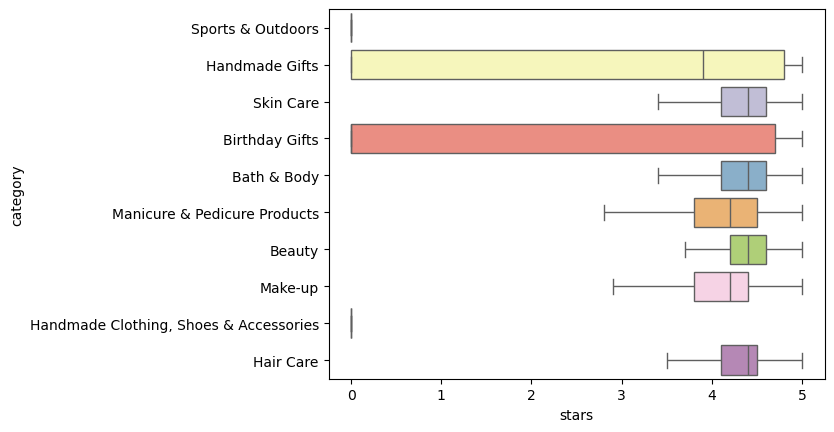

In [ ]:
sns.boxplot(data=df_ratings_top10, x='stars', y='category', palette='Set3', showfliers=False)

In [ ]:
1. **Correlation Coefficients**:
    - Calculate the correlation coefficient between `price` and `stars`.
    - Is there a significant correlation between product price and its rating?
	

In [ ]:
pearson_corr = df_clean['price'].corr(df_clean['stars'], method='pearson')
spearman_corr = df_clean['price'].corr(df_clean['stars'], method='spearman')

print(f"Coeficiente de Pearson: {pearson_corr:.4f}")
print(f"Coeficiente de Spearman: {spearman_corr:.4f}")

Coeficiente de Pearson: -0.0777
Coeficiente de Spearman: -0.0668


In [ ]:
2. **Visualizations**:
    - Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe? tenemos muchas 0 estrellas en todos los precios. 1 estrella y luego hay distribucion sobretodo de 2 a 5 estrellas entre los productos de 0 a 40 euros, i como más caro, más distribución de extremos encontramos.
    - Use a correlation heatmap to visualize correlations between all numerical variables.
    - Examine if product prices typically follow a normal distribution using a QQ plot. 

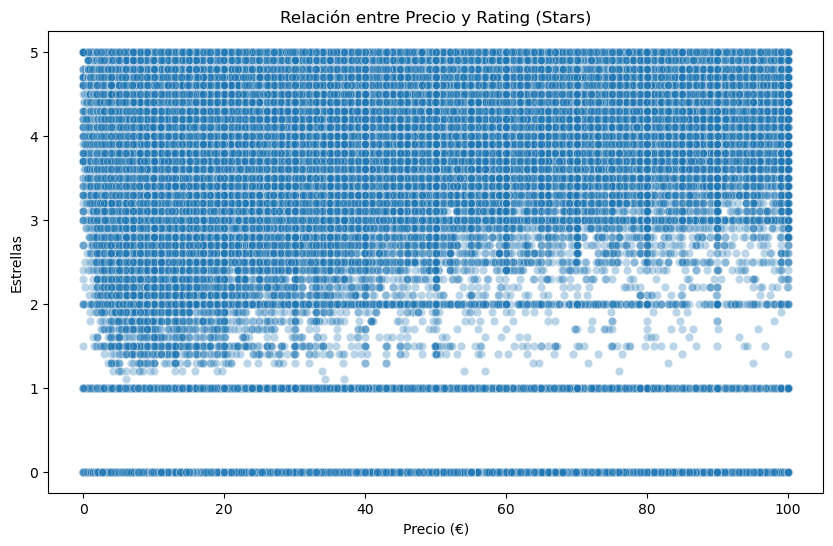

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_clean, x='price', y='stars', alpha=0.1)
plt.title('Relación entre Precio y Rating (Stars)')
plt.xlabel('Precio (€)')
plt.ylabel('Estrellas')
plt.show()

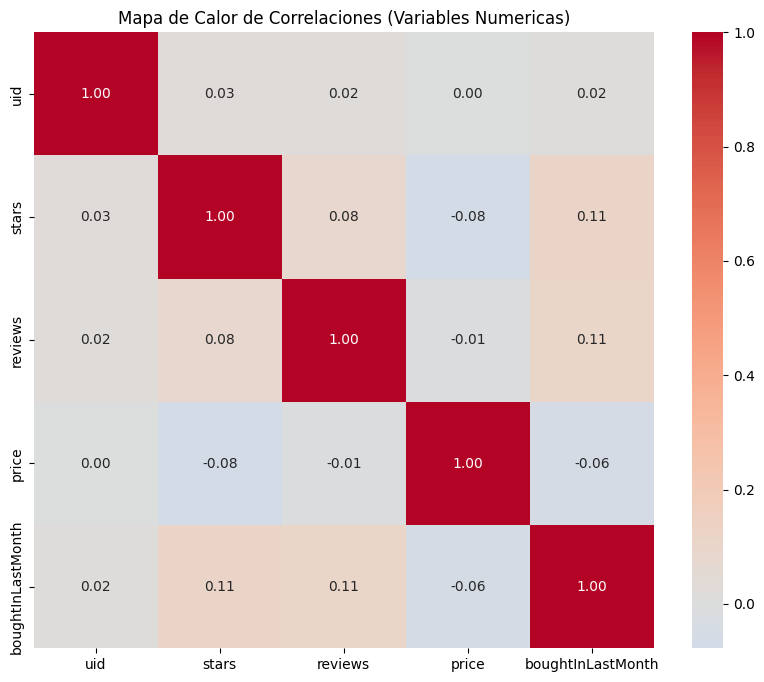

In [5]:
df_numeric = df_clean.select_dtypes(include=['number'])
corr_matrix = df_numeric.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0)

plt.title('Mapa de Calor de Correlaciones (Variables Numericas)')
plt.show()

In [6]:
stats.probplot(df_clean['price'], dist="norm", plot=plt)

plt.title('QQ Plot: Comprovación de Normalidad del Precio')
plt.xlabel('Quantiles')
plt.ylabel('Valors de precio observado')
plt.show()

NameError: name 'stats' is not defined